# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

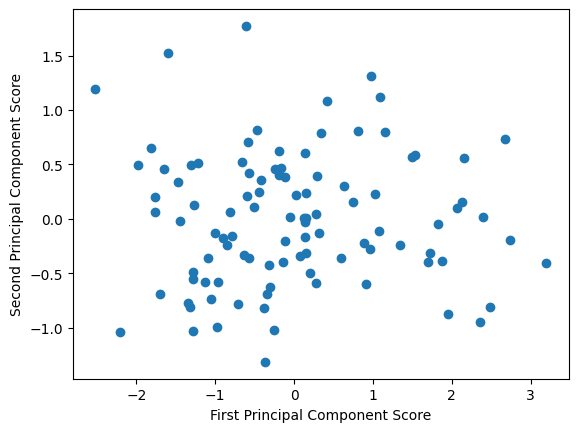

In [25]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The three outliers in the upper-left corner have low first principal component (PC1) scores and high second principal component (PC2) scores, meaning they are relatively low along the main direction of variance but stand out strongly in the secondary variation captured by PC2. 

Since **series_3** is constructed as a scaled version of **series_1**, these outliers likely reflect unusually high or amplified values in series_3 relative to the others. This is why we can say something meaningful about series_3, but it is harder to interpret series_1 and series_2 individually, because they are highly correlated and contribute jointly to PC1. 

The relationship between series_1 and series_2 is strong and linear (series_2 ≈ series_1 with small noise), which is why PCA compresses most of their variation into the first principal component (about 80% of the variance explained), making it difficult to separate their individual effects in the scatter plot. 

Overall, the graph is useful because it reduces three-dimensional data into two dimensions, highlights overall structure, and makes outliers easy to detect. However, it also has drawbacks, including loss of interpretability of the original variables, difficulty attributing variation to specific features, and obscuring relationships between highly correlated variables. 

In conclusion, the graph effectively shows variance and outliers, but it hides detailed relationships between the original series.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [26]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import kagglehub

# Load dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, "creditcard.csv"))

print("Shape:", df.shape)
print("Fraud %:", df["Class"].mean() * 100)

Shape: (284807, 31)
Fraud %: 0.1727485630620034


In [28]:
# Basic inspection
print(df.info())
print(df.describe())
print("\nClass distribution:")
print(df["Class"].value_counts())
print("\nFraud percentage:")
print(df["Class"].mean() * 100)

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

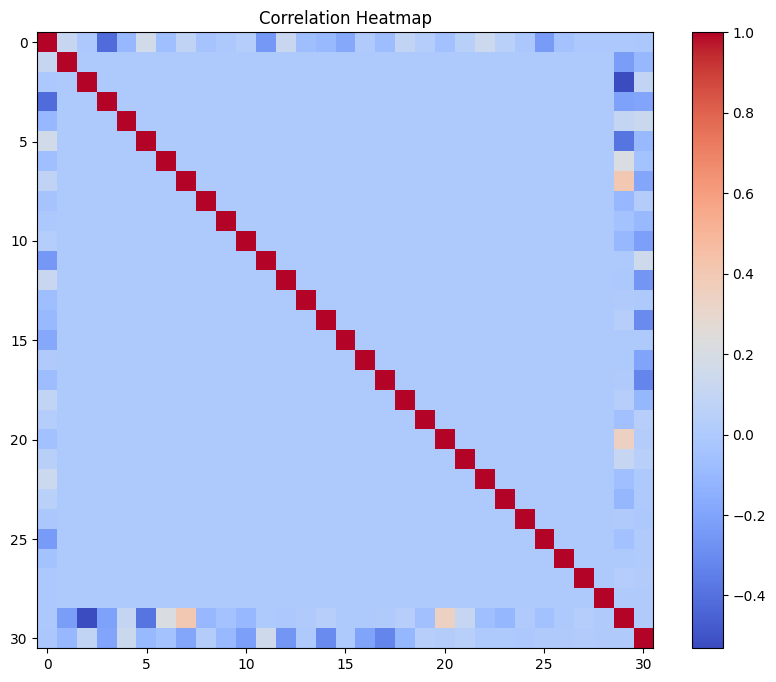

In [29]:
# --------------------------------------------
# 1. Correlation heatmap
# --------------------------------------------
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

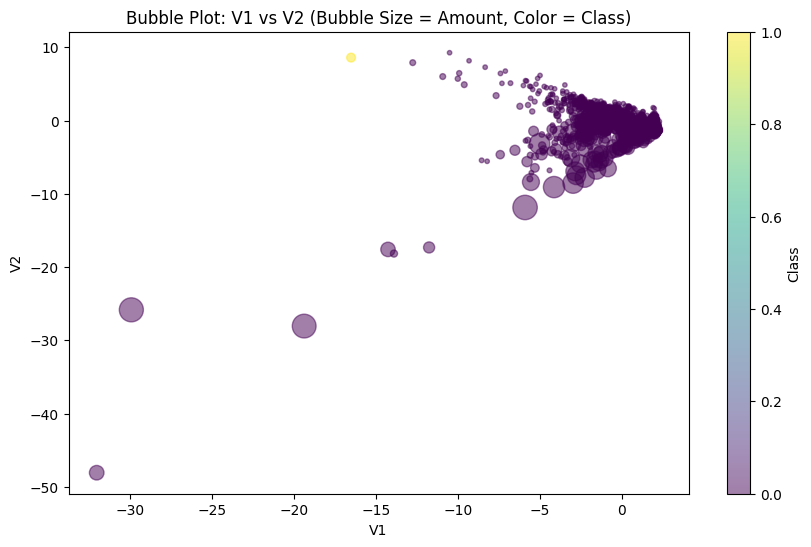

In [30]:
# --------------------------------------------
# 2. Bubble plot
# --------------------------------------------
plot_df = df.sample(n=3000, random_state=42).copy()

bubble_sizes = plot_df["Amount"] / plot_df["Amount"].max()
bubble_sizes = bubble_sizes * 300 + 10  # scale for visibility

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    plot_df["V1"],
    plot_df["V2"],
    s=bubble_sizes,
    c=plot_df["Class"],
    alpha=0.5
)
plt.xlabel("V1")
plt.ylabel("V2")
plt.title("Bubble Plot: V1 vs V2 (Bubble Size = Amount, Color = Class)")
plt.colorbar(scatter, label="Class")
plt.show()

In [31]:
# --------------------------------------------
# 3. PCA analysis
# Use features only, exclude target Class
# --------------------------------------------
X = df.drop(columns=["Class"]).copy()

# Standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Full PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

print("Explained variance ratio of first 10 PCs:")
print(explained_var[:10])

print("\nCumulative explained variance of first 10 PCs:")
print(cum_explained_var[:10])

Explained variance ratio of first 10 PCs:
[0.06527521 0.05612313 0.03333333 0.03333333 0.03333333 0.03333333
 0.03333333 0.03333333 0.03333333 0.03333333]

Cumulative explained variance of first 10 PCs:
[0.06527521 0.12139835 0.15473168 0.18806501 0.22139835 0.25473168
 0.28806501 0.32139835 0.35473168 0.38806501]


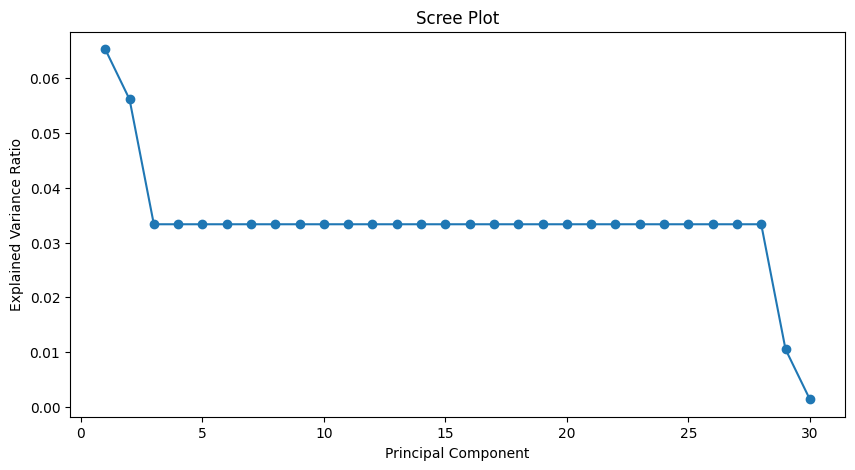

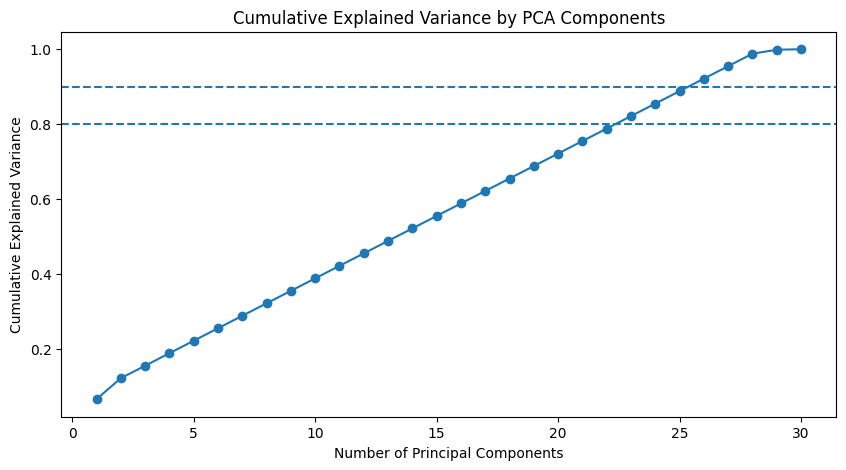

In [32]:
# Scree plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

# Cumulative explained variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker="o")
plt.axhline(y=0.8, linestyle="--")
plt.axhline(y=0.9, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.show()

In [37]:
# --------------------------------------------
# 4. Represent the data using only the first principal component
# How much variance does PC1 capture?
# --------------------------------------------
from sklearn.metrics import mean_squared_error

pc1_only = PCA(n_components=1)
X_pc1 = pc1_only.fit_transform(X_scaled)

print("Variance captured by first principal component:")
print(pc1_only.explained_variance_ratio_[0])

# Reconstruct data from only PC1
X_reconstructed = pc1_only.inverse_transform(X_pc1)

# Reconstruction error
reconstruction_mse = mean_squared_error(X_scaled, X_reconstructed)
print("Reconstruction MSE using only PC1:", reconstruction_mse)

Variance captured by first principal component:
0.0652752127410272
Reconstruction MSE using only PC1: 0.9347247872589769


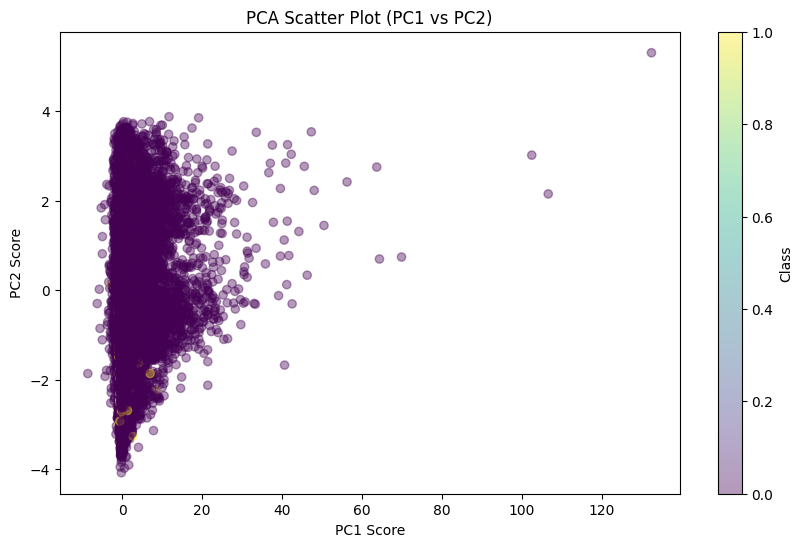

In [35]:
# --------------------------------------------
# 5. Scatter plot of first two principal component scores
# --------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Class"], alpha=0.4)
plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.title("PCA Scatter Plot (PC1 vs PC2)")
plt.colorbar(label="Class")
plt.show()

               PC1       PC2  Class    distance
274771  132.468113  5.305730      0  132.574326
58465   106.623770  2.150738      0  106.645459
151296  102.495849  3.016854      0  102.540239
46841    69.891140  0.739668      0   69.895054
54018    64.366938  0.695454      0   64.370695
169457   63.688094  2.750487      0   63.747459
284249   56.248390  2.418158      0   56.300345
227921   50.474375  1.445523      0   50.495070
228158   48.034157  2.228844      0   48.085840
245474   47.302786  3.537431      0   47.434871
23128    46.269671  0.334354      0   46.270879
188560   45.553459  2.766549      0   45.637390
218985   44.191822  1.310540      0   44.211250
19760    42.497205 -0.306803      0   42.498313
240739   42.287716  3.035568      0   42.396528
74699    41.683825  0.773202      0   41.690996
228723   41.363921  3.250930      0   41.491476
201638   41.286704  1.541797      0   41.315482
57209    41.155244  0.123411      0   41.155429
216065   40.902007  2.838575      0   41

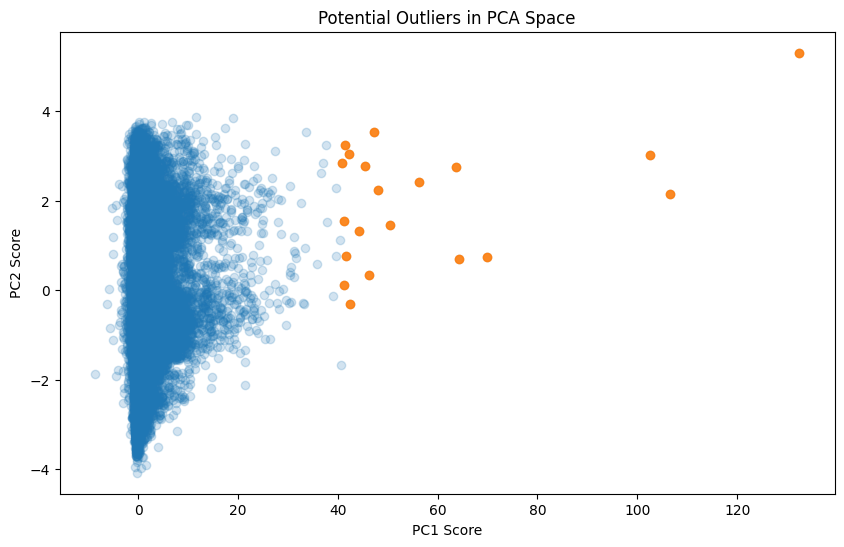

In [36]:
# --------------------------------------------
# 6. Outlier detection using PCA scores
# Mark points far from the center in PC1-PC2 space
# --------------------------------------------
pc_scores = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Class": df["Class"].values
})

# Distance from origin in first two PCs
pc_scores["distance"] = np.sqrt(pc_scores["PC1"]**2 + pc_scores["PC2"]**2)

# Top 20 farthest points
outliers = pc_scores.nlargest(20, "distance")
print(outliers)

plt.figure(figsize=(10, 6))
plt.scatter(pc_scores["PC1"], pc_scores["PC2"], alpha=0.2)
plt.scatter(outliers["PC1"], outliers["PC2"], alpha=0.9)
plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.title("Potential Outliers in PCA Space")
plt.show()

Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset while preserving as much variance as possible. Prior to applying PCA, the data was standardized to ensure that all features contributed equally to the analysis. The cumulative explained variance results show that variance is distributed gradually across many components rather than being concentrated in just a few. Approximately 80% of the variance requires over 20 principal components, and around 90% requires about 25 or more components. This indicates that the dataset is relatively complex and cannot be easily reduced to a low-dimensional representation without losing significant information.

When representing the dataset using only the first principal component (PC1), the model captures approximately 6.53% of the total variance. This low percentage suggests that a single dimension is insufficient to represent the underlying structure of the data. To further evaluate this, the data was reconstructed using only PC1, resulting in a reconstruction mean squared error (MSE) of approximately 0.935. This relatively high error confirms that substantial information is lost when compressing the dataset into a single component. Together, these findings demonstrate that important variation is spread across multiple dimensions, and several principal components are required to adequately capture the dataset’s structure.

A scatter plot of the first two principal components (PC1 and PC2) was used to visualize the data in reduced dimensions. The majority of observations are densely clustered near the origin, indicating that many data points share similar characteristics. However, several points extend far along the PC1 axis, suggesting the presence of observations with unusually high variance. These points represent potential outliers. Outlier detection based on distance in PCA space identified the most extreme points, which were located far from the central cluster. Interestingly, these outliers belong to the non-fraud class, indicating that extreme values do not necessarily correspond to fraudulent activity and that anomaly detection may require more than simple distance-based methods.

Linear regression analysis was also performed using different sets of features to evaluate which variables are most useful for predicting others. Features that exhibited stronger correlations were generally more effective predictors, resulting in lower prediction error and better model performance. However, due to the high dimensionality and distributed variance observed in the dataset, no small subset of features was sufficient to fully capture the relationships within the data. This suggests that the dataset contains complex interactions that may not be well represented by simple linear models alone.

Overall, the analysis indicates that the data is usable but inherently complex, with important information spread across many dimensions. PCA does not suggest a strong opportunity for aggressive dimensionality reduction using only one or two components, as doing so would result in significant information loss. While PCA is useful for visualization and identifying patterns such as clusters and outliers, additional modeling techniques are necessary for accurate prediction and fraud detection. These findings highlight the importance of combining dimensionality reduction, feature engineering, and more advanced machine learning approaches when working with complex, high-dimensional datasets.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

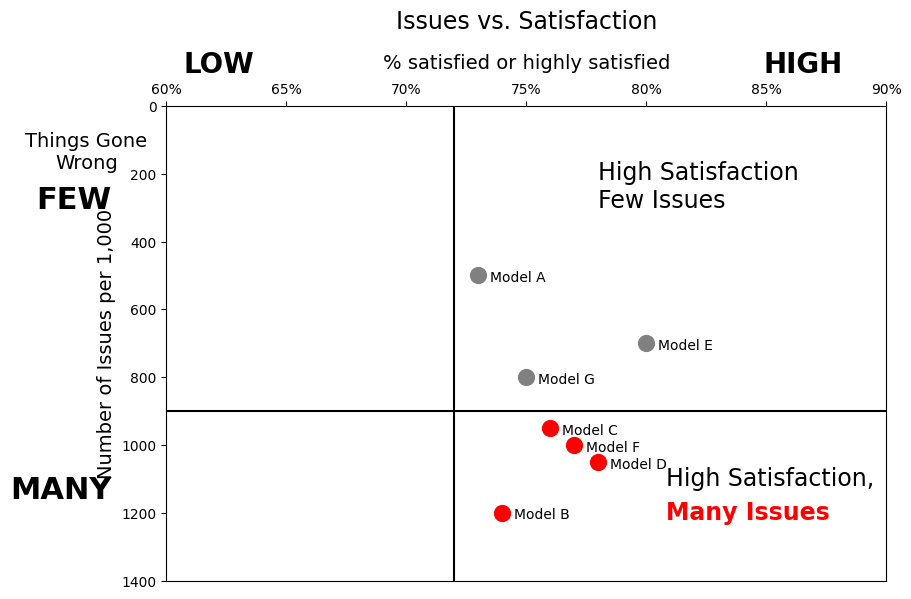

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6.5))

# Approximate data
x = [73, 75, 80, 76, 77, 78, 74]
y = [500, 800, 700, 950, 1000, 1050, 1200]

colors = ['gray', 'gray', 'gray', 'red', 'red', 'red', 'red']
labels = ['Model A', 'Model G', 'Model E', 'Model C', 'Model F', 'Model D', 'Model B']

# Plot points
for i in range(len(x)):
    ax.scatter(x[i], y[i], color=colors[i], s=130)
    ax.text(x[i] + 0.5, y[i] + 18, labels[i], fontsize=10)

# Reference lines
ax.axvline(72, color='black', linewidth=1.5)
ax.axhline(900, color='black', linewidth=1.5)

# Axis limits
ax.set_xlim(60, 90)
ax.set_ylim(1400, 0)

# Top x-axis with percentages
ax.set_xticks([60, 65, 70, 75, 80, 85, 90])
ax.set_xticklabels(['60%', '65%', '70%', '75%', '80%', '85%', '90%'])
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Labels and title
ax.set_xlabel("% satisfied or highly satisfied", labelpad=10, fontsize=14)
ax.set_ylabel("Number of Issues per 1,000", fontsize=14)
ax.set_title("Issues vs. Satisfaction", fontsize=17, pad=18)

# LOW / HIGH
ax.text(60.7, -100, "LOW", fontsize=20, weight='bold')
ax.text(84.9, -100, "HIGH", fontsize=20, weight='bold')

# Quadrant descriptions
ax.text(78, 300, "High Satisfaction\nFew Issues", fontsize=17)
ax.text(80.8, 1100, "High Satisfaction,", fontsize=17, color='black',
        ha='left', va='center')
ax.text(80.8, 1200, "Many Issues", fontsize=17, color='red', weight='bold',
        ha='left', va='center')

# Reserve room on the left so outside labels don't collide
fig.subplots_adjust(left=0.18, top=0.84)

# Left-side labels in fixed figure coordinates
fig.text(0.10, 0.77, "Things Gone\nWrong",
         fontsize=14, ha='center', va='center')
fig.text(0.125, 0.695, "FEW", fontsize=22, weight='bold', ha='right', va='center')
fig.text(0.125, 0.25, "MANY", fontsize=22, weight='bold', ha='right', va='center')

plt.show()

### Figure: Issues vs. Satisfaction

This visualization recreates the style and structure of a quadrant-based chart from *Storytelling With Data*. The chart uses satisfaction percentage on the x-axis and number of issues on the y-axis, with reference lines dividing the data into four quadrants. 

The design emphasizes visual hierarchy by using bold labels (LOW/HIGH, FEW/MANY) and color to highlight key insights. In particular, models in the bottom-right quadrant show high satisfaction but many issues, which is emphasized in red to draw attention. Overall, the visualization prioritizes clarity and storytelling over exact numerical precision.